In [32]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import datetime

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [34]:
scaler = StandardScaler()
X_train_scaled = X_train #scaler.fit_transform(X_train)
X_test_scaled = X_test#scaler.transform(X_test)

In [35]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [36]:
model = Sequential([
    Dense(100, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(50, activation='relu'),
    Dense(1)
])

C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=500,
    callbacks=[tensorboard_callback, EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=1
)

Epoch 1/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1445.8636 - mae: 29.1762 - val_loss: 3436.5225 - val_mae: 20.6097
Epoch 2/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5856.9453 - mae: 21.2903 - val_loss: 177.3210 - val_mae: 9.5106
Epoch 3/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 163.2388 - mae: 9.1201 - val_loss: 137.4150 - val_mae: 8.4214
Epoch 4/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 128.5079 - mae: 8.0609 - val_loss: 121.4249 - val_mae: 7.7791
Epoch 5/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 255.8589 - mae: 8.9635 - val_loss: 168.5292 - val_mae: 9.2409
Epoch 6/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 924.3051 - mae: 12.7561 - val_loss: 212.3291 - val_mae: 10.1216
Epoch 7/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 544.8143 - mae: 12.6074 - val_loss: 927.4219 - val_mae: 14.0901
Epoch 8/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 337.6391 - mae: 11.6103 - val_loss: 104.7883 - val_mae: 7.3872
Epoch 9/500
59

In [38]:
y_pred = model.predict(X_test_scaled).flatten()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [39]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 20.88932034863619
Mean Absolute Error (MAE): 3.4281302562599016
R-squared (R²): 0.7749930620193481


In [40]:
import json

metrics = {
    "MAE": mae,
    "MSE": mse,
    "R2": r2
}

with open(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\metrics\bigbraintime_metrics.json", "w") as f:
    json.dump(metrics, f)

In [41]:
import pickle

with open(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\bigbraintime_model.pkl", "wb") as f:
    pickle.dump(model, f)

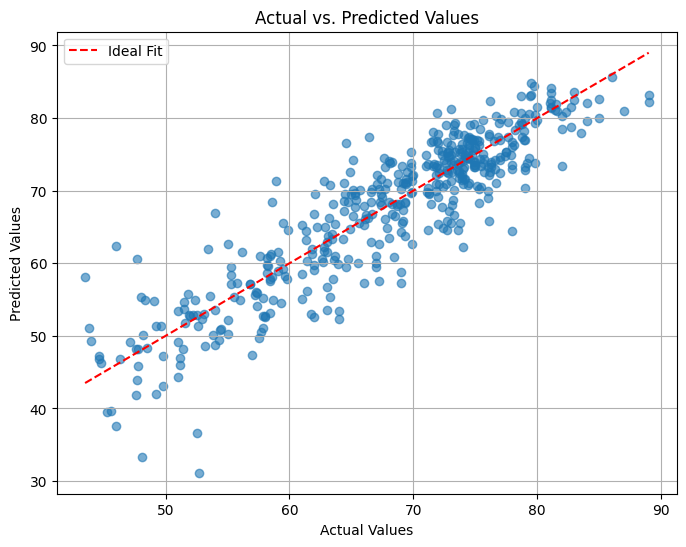

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\bigbraintime\1.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
residuals = y_test.values.flatten() - y_pred.flatten()

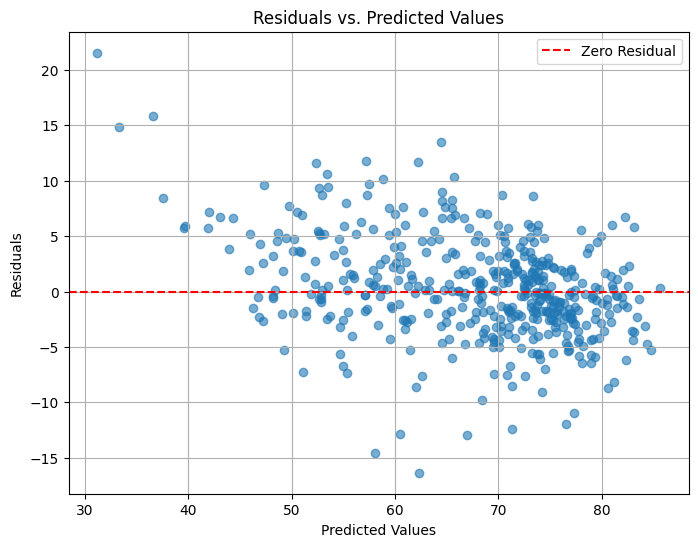

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\bigbraintime\2.png", dpi=300, bbox_inches="tight")
plt.show()

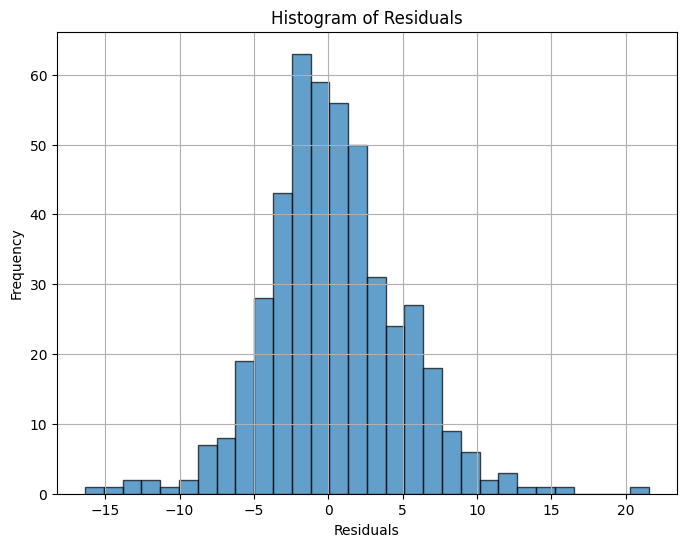

In [45]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\bigbraintime\3.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:

print(f"tensorboard --logdir {log_dir}")

tensorboard --logdir logs/fit/20250123-114333
